# CMPE 255 Assignment 1
## End-to-End Customer Churn Prediction Using AI-Assisted Data Science

### Project Overview
In this project, I use ChatGPT as an AI-assisted data science tool to perform an end-to-end machine learning workflow on the Telco Customer Churn dataset.

The main goal is to predict whether a telecommunications customer will churn based on customer demographics, subscribed services, account information, contract type, tenure, and billing behavior.

This project follows a structured data science workflow inspired by CRISP-DM:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Exploratory Data Analysis
5. Feature Engineering and Preprocessing
6. Machine Learning Modeling
7. Model Evaluation and Comparison
8. Model Interpretation
9. Business Insights and Conclusion

### Machine Learning Problem
This is a supervised binary classification problem.

**Target variable:** `Churn`

- `Yes` = the customer left the company
- `No` = the customer remained with the company

### Objective
The objectives of this analysis are to:

- Understand the structure and quality of the Telco Customer Churn dataset.
- Identify patterns associated with customer churn.
- Build multiple machine learning classification models.
- Compare the models using appropriate evaluation metrics.
- Identify important features associated with customer churn.
- Translate the model results into meaningful business insights.

In [95]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [96]:
# Load the Telco Customer Churn dataset
file_path = "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (7043, 21)


## 1. Data Understanding

The first stage of the analysis is to understand the structure of the dataset.  
I will inspect the number of rows and columns, preview several customer records, examine data types, and review basic descriptive statistics.

This step helps identify potential data quality issues before performing visualization or machine learning.

In [97]:
# Display the first five rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [98]:
# Check the number of rows and columns
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 7043
Number of columns: 21


In [99]:
# Display all column names
print("Columns in the dataset:")

for column in df.columns:
    print(column)

Columns in the dataset:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [100]:
# Check column data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [101]:
# Generate descriptive statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Initial Observations

The dataset contains 7,043 customer records and 21 columns.

From the initial inspection:

- Most customer-related categorical variables are stored as `object`.
- `tenure` and `SeniorCitizen` are stored as integers.
- `MonthlyCharges` is correctly stored as a numerical variable.
- `TotalCharges` is stored as an `object`, although it represents a monetary value and should normally be numerical. This suggests that the column may contain non-numeric or blank values that require further investigation.
- The target variable `Churn` is categorical and contains the customer churn outcome.

The descriptive statistics also show that the average customer tenure is approximately 32.37 months, while the average monthly charge is approximately $64.76.

Before performing exploratory data analysis and machine learning, the dataset should be checked for missing values, duplicate records, and invalid values.

In [102]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [103]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [104]:
# Examine unique values in categorical columns
# Exclude customerID because it is only an identifier

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    if column != 'customerID':
        print("\nColumn:", column)
        print(df[column].unique())


Column: gender
['Female' 'Male']

Column: Partner
['Yes' 'No']

Column: Dependents
['No' 'Yes']

Column: PhoneService
['No' 'Yes']

Column: MultipleLines
['No phone service' 'No' 'Yes']

Column: InternetService
['DSL' 'Fiber optic' 'No']

Column: OnlineSecurity
['No' 'Yes' 'No internet service']

Column: OnlineBackup
['Yes' 'No' 'No internet service']

Column: DeviceProtection
['No' 'Yes' 'No internet service']

Column: TechSupport
['No' 'Yes' 'No internet service']

Column: StreamingTV
['No' 'Yes' 'No internet service']

Column: StreamingMovies
['No' 'Yes' 'No internet service']

Column: Contract
['Month-to-month' 'One year' 'Two year']

Column: PaperlessBilling
['Yes' 'No']

Column: PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Column: TotalCharges
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Column: Churn
['No' 'Yes']


In [105]:
# Investigate the TotalCharges column
print("Data type of TotalCharges:", df['TotalCharges'].dtype)

# Convert TotalCharges to numeric temporarily
# Invalid values will become NaN
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Invalid or missing TotalCharges values:",
      total_charges_numeric.isnull().sum())

Data type of TotalCharges: object
Invalid or missing TotalCharges values: 11


In [106]:
# Display rows where TotalCharges cannot be converted to a number
invalid_total_charges = df[total_charges_numeric.isnull()]

invalid_total_charges[
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [107]:
# Examine the target variable
print("Churn counts:")
print(df['Churn'].value_counts())

print("\nChurn percentages:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 2. Data Cleaning

The initial data quality assessment identified an important issue in the `TotalCharges` column.

Although `TotalCharges` represents a monetary value, it was stored as an `object` data type. Further investigation showed that 11 records contained blank values that could not be converted directly to numbers.

All 11 of these customers have a `tenure` value of 0, indicating that they are new customers who have not yet accumulated total charges. Instead of removing these customers, the blank `TotalCharges` values will be replaced with 0. This preserves valid customer records while maintaining a logical interpretation of the data.

The target variable is also moderately imbalanced:

- No Churn: 5,174 customers (73.46%)
- Churn: 1,869 customers (26.54%)

Because of this imbalance, model performance will later be evaluated using multiple metrics rather than accuracy alone, including precision, recall, F1-score, ROC-AUC, and the confusion matrix.

In [108]:
# Convert TotalCharges from object to numeric
# Invalid blank values are converted to NaN
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Fill missing TotalCharges values with 0
# These records correspond to new customers with tenure = 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("TotalCharges data type:", df['TotalCharges'].dtype)
print("Missing TotalCharges values:", df['TotalCharges'].isnull().sum())

TotalCharges data type: float64
Missing TotalCharges values: 0


In [109]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [110]:
# Check whether customerID is unique
unique_customers = df['customerID'].nunique()

print("Number of rows:", len(df))
print("Number of unique customer IDs:", unique_customers)

Number of rows: 7043
Number of unique customer IDs: 7043


In [111]:
# Final data quality check after cleaning
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (7043, 21)

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     

## 3. Exploratory Data Analysis

After cleaning the dataset, exploratory data analysis (EDA) is performed to better understand customer behavior and identify patterns associated with churn.

The analysis focuses on several important questions:

1. How common is customer churn?
2. Is churn associated with contract type?
3. How does customer tenure relate to churn?
4. Are monthly charges different between churned and retained customers?
5. Does internet service type affect churn behavior?
6. Which other customer characteristics appear to be associated with churn?

These observations will help guide feature preprocessing and machine learning model development.

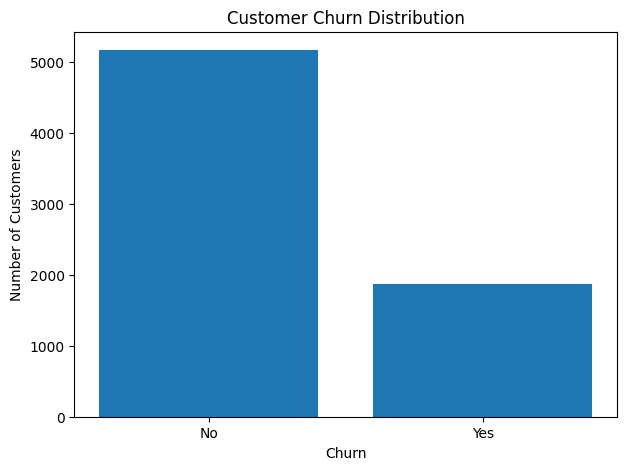

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [112]:
# Calculate churn counts
churn_counts = df['Churn'].value_counts()

# Create bar chart
plt.figure(figsize=(7, 5))
plt.bar(churn_counts.index, churn_counts.values)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

# Display exact values
print(churn_counts)
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

### Observation: Churn Distribution

The dataset contains considerably more non-churned customers than churned customers. Approximately 73.46% of customers remained with the company, while 26.54% churned.

This indicates a moderate class imbalance. Therefore, accuracy alone may not be sufficient for evaluating the machine learning models. Metrics such as precision, recall, F1-score, ROC-AUC, and the confusion matrix will also be considered.

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


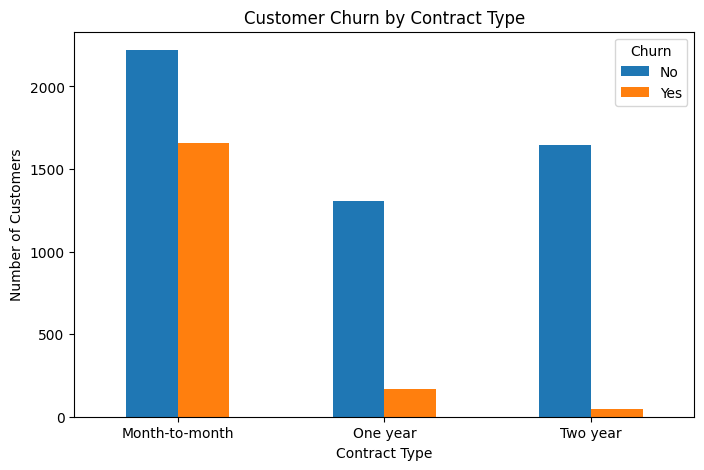

In [113]:
# Create a cross-tabulation of Contract and Churn
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn']
)

print(contract_churn)

# Visualize churn by contract type
contract_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [114]:
# Calculate churn rate for each contract type
contract_churn_rate = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn_rate)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


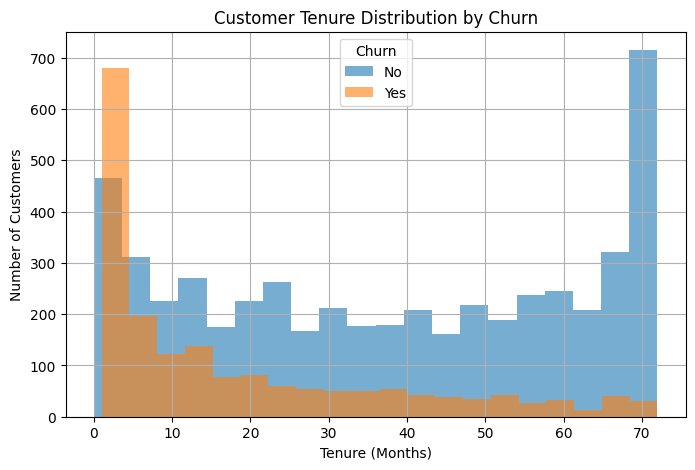

Average tenure by churn status:
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [115]:
# Compare customer tenure between churn groups
plt.figure(figsize=(8, 5))

df[df['Churn'] == 'No']['tenure'].hist(
    bins=20,
    alpha=0.6,
    label='No'
)

df[df['Churn'] == 'Yes']['tenure'].hist(
    bins=20,
    alpha=0.6,
    label='Yes'
)

plt.title('Customer Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

plt.show()

# Compare average tenure
print("Average tenure by churn status:")
print(df.groupby('Churn')['tenure'].mean())

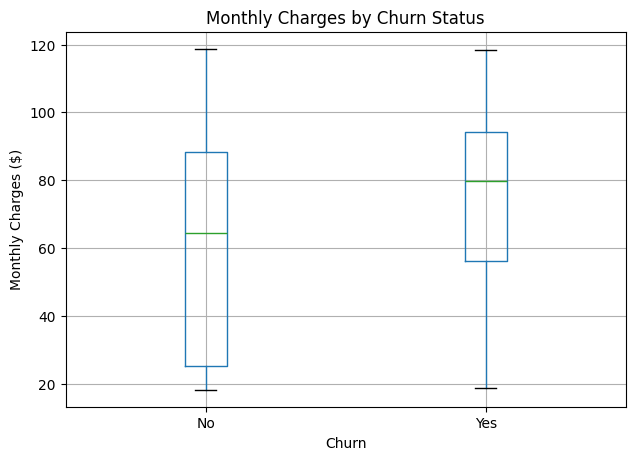

Average Monthly Charges by churn status:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [116]:
# Compare MonthlyCharges between churn groups
df.boxplot(
    column='MonthlyCharges',
    by='Churn',
    figsize=(7, 5)
)

plt.title('Monthly Charges by Churn Status')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')

plt.show()

# Display average monthly charges
print("Average Monthly Charges by churn status:")
print(df.groupby('Churn')['MonthlyCharges'].mean())

### EDA Findings and Interpretation

#### 1. Contract Type and Customer Churn

Contract type shows a strong relationship with customer churn.

The dataset contains:

- Month-to-month contracts: 2,220 retained customers and 1,655 churned customers.
- One-year contracts: 1,307 retained customers and 166 churned customers.
- Two-year contracts: 1,647 retained customers and only 48 churned customers.

Customers with month-to-month contracts appear much more likely to churn, while customers with longer-term contracts show substantially lower churn.

This suggests that contract commitment may be an important factor in customer retention. Long-term contracts could provide greater customer stability, while month-to-month customers represent a higher-risk group for churn.

#### 2. Customer Tenure and Churn

Customer tenure also shows a clear relationship with churn.

The average tenure is:

- No churn: approximately 37.57 months
- Churn: approximately 17.98 months

Customers who churn tend to have much shorter relationships with the company. The tenure distribution also shows a particularly high number of churned customers among customers with relatively low tenure.

This suggests that the early stage of the customer relationship may be especially important for retention. Newer customers may require additional engagement or retention strategies.

#### 3. Monthly Charges and Churn

Customers who churn also tend to have higher monthly charges.

The average monthly charge is:

- No churn: approximately $61.27
- Churn: approximately $74.44

The boxplot similarly shows that the distribution of monthly charges for churned customers is shifted toward higher values.

This suggests that higher monthly costs may be associated with increased churn risk. However, this relationship should not be interpreted as causal because other factors, such as service type and contract type, may also influence both monthly charges and churn.

Churn rate by Internet Service:
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


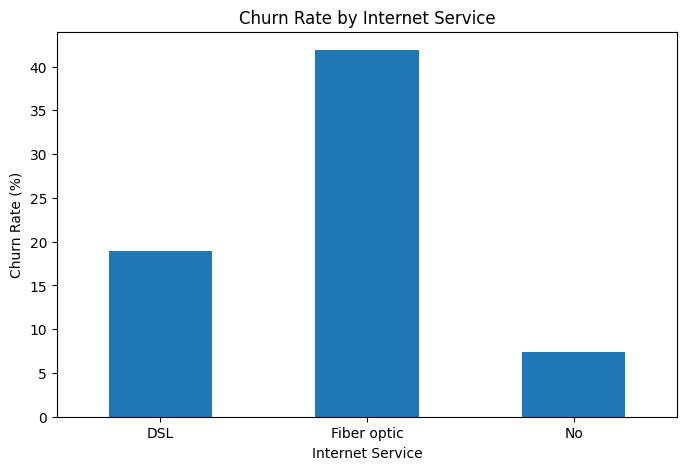

In [117]:
# Analyze churn by Internet Service type
internet_churn_rate = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn rate by Internet Service:")
print(internet_churn_rate)

# Visualize the churn rate
internet_churn_rate['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

Churn rate by Payment Method:
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


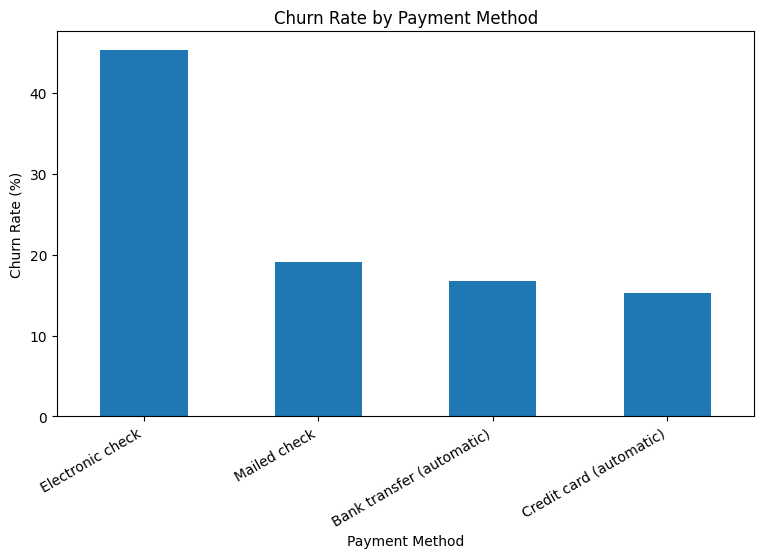

In [118]:
# Analyze churn rate by Payment Method
payment_churn_rate = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn rate by Payment Method:")
print(payment_churn_rate)

# Visualize churn rate
payment_churn_rate['Yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30, ha='right')

plt.show()

In [119]:
# Select numerical variables for correlation analysis
numerical_data = df[
    [
        'SeniorCitizen',
        'tenure',
        'MonthlyCharges',
        'TotalCharges'
    ]
]

correlation_matrix = numerical_data.corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.103006
tenure               0.016567  1.000000        0.247900      0.826178
MonthlyCharges       0.220173  0.247900        1.000000      0.651174
TotalCharges         0.103006  0.826178        0.651174      1.000000


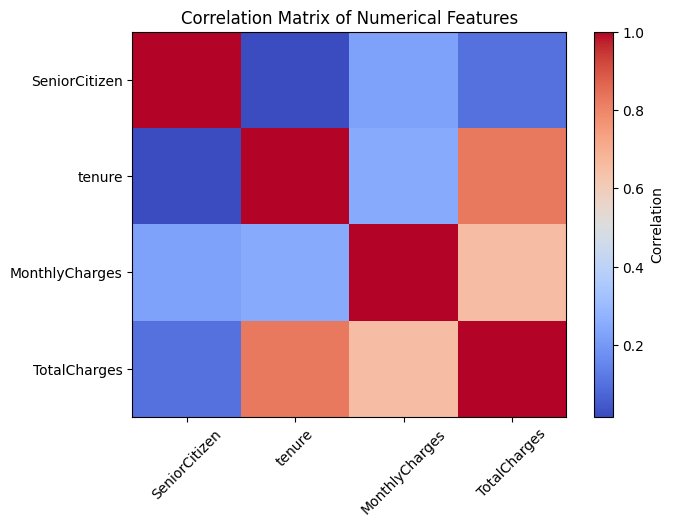

In [120]:
# Visualize the correlation matrix
plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    cmap='coolwarm',
    aspect='auto'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

### EDA Summary and Business Insights

The exploratory data analysis revealed several important patterns associated with customer churn.

#### Contract Type
Contract type shows one of the strongest relationships with churn. The churn rate for month-to-month customers is approximately 42.71%, compared with 11.27% for one-year contracts and only 2.83% for two-year contracts. This suggests that customers with longer-term commitments are substantially less likely to leave the company.

#### Customer Tenure
Customers who churn have a much shorter average tenure. Churned customers have an average tenure of approximately 17.98 months, compared with 37.57 months for retained customers. This suggests that the earlier stages of the customer relationship may represent an important period for customer retention.

#### Monthly Charges
Churned customers pay higher monthly charges on average. Their average monthly charge is approximately $74.44, compared with $61.27 among customers who remain with the company.

#### Internet Service
Fiber optic customers have the highest churn rate at approximately 41.89%. This is considerably higher than DSL customers at approximately 18.96% and customers without internet service at approximately 7.40%.

#### Payment Method
Customers using electronic checks have the highest churn rate at approximately 45.29%. In comparison, customers using automatic bank transfers or automatic credit card payments have churn rates of approximately 16.71% and 15.24%, respectively.

#### Numerical Correlations
The correlation analysis shows a strong positive relationship between `tenure` and `TotalCharges` (approximately 0.83). `MonthlyCharges` and `TotalCharges` also show a moderately strong positive correlation (approximately 0.65). These relationships are reasonable because total accumulated charges are influenced by both the duration of the customer relationship and monthly service costs.

### Overall EDA Conclusion

The analysis suggests that customers with month-to-month contracts, shorter tenure, higher monthly charges, fiber optic internet service, and electronic check payments represent potentially higher-risk customer groups.

These findings describe associations in the dataset and should not automatically be interpreted as causal relationships. The next stage will use machine learning to determine whether customer churn can be predicted from these characteristics.

## 4. Data Preprocessing for Machine Learning

Before training machine learning models, the dataset must be transformed into a format suitable for classification algorithms.

The preprocessing process includes:

1. Separating the target variable (`Churn`) from the input features.
2. Removing `customerID` because it is a unique identifier rather than a meaningful predictive feature.
3. Converting the target variable into binary values.
4. Separating numerical and categorical features.
5. Encoding categorical variables using one-hot encoding.
6. Scaling numerical features where appropriate.
7. Splitting the dataset into training and testing sets.

To reduce data leakage, preprocessing transformations will be learned from the training data through a machine learning pipeline rather than being applied to the entire dataset before the train-test split.

In [121]:
# Import preprocessing and machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Machine learning libraries imported successfully!")

Machine learning libraries imported successfully!


In [122]:
# Separate input features and target variable

# customerID is removed because it is only a unique identifier
X = df.drop(columns=['customerID', 'Churn'])

# Convert target variable:
# No = 0, Yes = 1
y = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [123]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 4
Number of categorical features: 15


In [124]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training feature shape: (5634, 19)
Testing feature shape: (1409, 19)

Training target distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [125]:
# Create preprocessing pipelines

# Numerical features will be standardized
numerical_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# Categorical features will be converted using one-hot encoding
categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(
            handle_unknown='ignore'
        ))
    ]
)

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numerical_transformer,
            numerical_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 5. Machine Learning Modeling

### Model 1: Logistic Regression

Logistic Regression is used as the first baseline classification model. It provides a relatively simple and interpretable starting point for predicting customer churn.

The preprocessing pipeline and classifier are combined into a single machine learning pipeline to ensure that preprocessing is learned only from the training data.

In [126]:
# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [127]:
# Make predictions using the test dataset
y_pred_logistic = logistic_model.predict(X_test)

# Obtain probabilities for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions completed!")

Predictions completed!


In [128]:
# Evaluate Logistic Regression

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1 Score:  {logistic_f1:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
F1 Score:  0.6040
ROC-AUC:   0.8421


In [129]:
# Display detailed classification report
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=['No Churn', 'Churn']
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Confusion Matrix:
[[926 109]
 [165 209]]


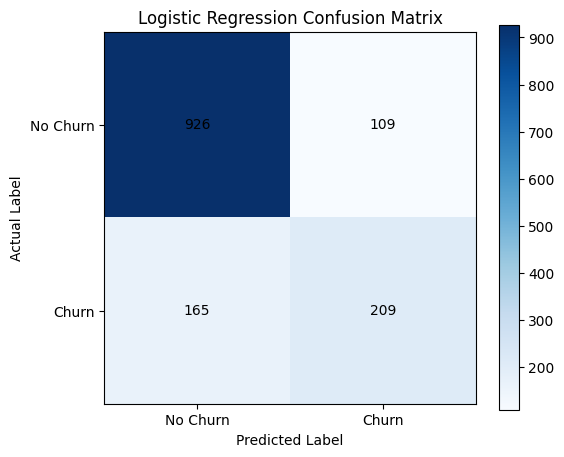

In [130]:
# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.yticks([0, 1], ['No Churn', 'Churn'])

# Add values inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()
plt.show()

### Logistic Regression Results and Interpretation

The Logistic Regression baseline model achieved the following performance:

- **Accuracy:** 80.55%
- **Precision:** 65.72%
- **Recall:** 55.88%
- **F1-score:** 60.40%
- **ROC-AUC:** 84.21%

The overall accuracy indicates that the model correctly classified approximately 81% of customers in the test dataset. However, because the dataset contains more non-churn customers than churn customers, accuracy alone does not provide a complete evaluation of model performance.

The ROC-AUC score of approximately 0.84 indicates that the model has a good overall ability to distinguish between customers who churn and customers who remain.

### Confusion Matrix Interpretation

The confusion matrix produced the following results:

- **True Negatives:** 926 customers were correctly predicted as non-churn.
- **False Positives:** 109 customers were predicted to churn but actually remained.
- **False Negatives:** 165 customers were predicted to remain but actually churned.
- **True Positives:** 209 customers were correctly identified as churned customers.

The churn recall is approximately 55.88%, meaning that the model successfully identifies slightly more than half of the customers who actually churn.

From a customer retention perspective, false negatives are particularly important because these customers are at risk of leaving but would not be identified by the model for potential retention actions.

Therefore, while Logistic Regression provides a strong baseline with good overall discrimination, there is still room to improve the identification of churned customers.

### Model 2: Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees. Unlike Logistic Regression, it can capture more complex and nonlinear relationships between customer characteristics and churn.

The model will be trained using the same training and testing datasets to allow a fair comparison with the Logistic Regression baseline.

In [131]:
# Create Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

# Train Random Forest
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [132]:
# Make Random Forest predictions
y_pred_rf = random_forest_model.predict(X_test)

# Obtain churn probabilities
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [133]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Random Forest Performance
-------------------------
Accuracy:  0.7835
Precision: 0.6186
Recall:    0.4813
F1 Score:  0.5414
ROC-AUC:   0.8206


### Model 3: Gradient Boosting

Gradient Boosting is another ensemble learning method that builds decision trees sequentially, with each new tree attempting to correct errors made by previous trees.

This provides a third modeling approach and allows the performance of linear and tree-based classification methods to be compared.

In [134]:
# Create Gradient Boosting pipeline
gradient_boosting_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

# Train Gradient Boosting
gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [135]:
# Make Gradient Boosting predictions
y_pred_gb = gradient_boosting_model.predict(X_test)

# Obtain churn probabilities
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting predictions completed!")

Gradient Boosting predictions completed!


In [136]:
# Evaluate Gradient Boosting

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting Performance")
print("-----------------------------")
print(f"Accuracy:  {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall:    {gb_recall:.4f}")
print(f"F1 Score:  {gb_f1:.4f}")
print(f"ROC-AUC:   {gb_roc_auc:.4f}")

Gradient Boosting Performance
-----------------------------
Accuracy:  0.8027
Precision: 0.6655
Recall:    0.5160
F1 Score:  0.5813
ROC-AUC:   0.8434


In [137]:
# Create model comparison table

model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Accuracy': [
        logistic_accuracy,
        rf_accuracy,
        gb_accuracy
    ],

    'Precision': [
        logistic_precision,
        rf_precision,
        gb_precision
    ],

    'Recall': [
        logistic_recall,
        rf_recall,
        gb_recall
    ],

    'F1 Score': [
        logistic_f1,
        rf_f1,
        gb_f1
    ],

    'ROC-AUC': [
        logistic_roc_auc,
        rf_roc_auc,
        gb_roc_auc
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Random Forest,0.7835,0.6186,0.4813,0.5414,0.8206
2,Gradient Boosting,0.8027,0.6655,0.5160,0.5813,0.8434


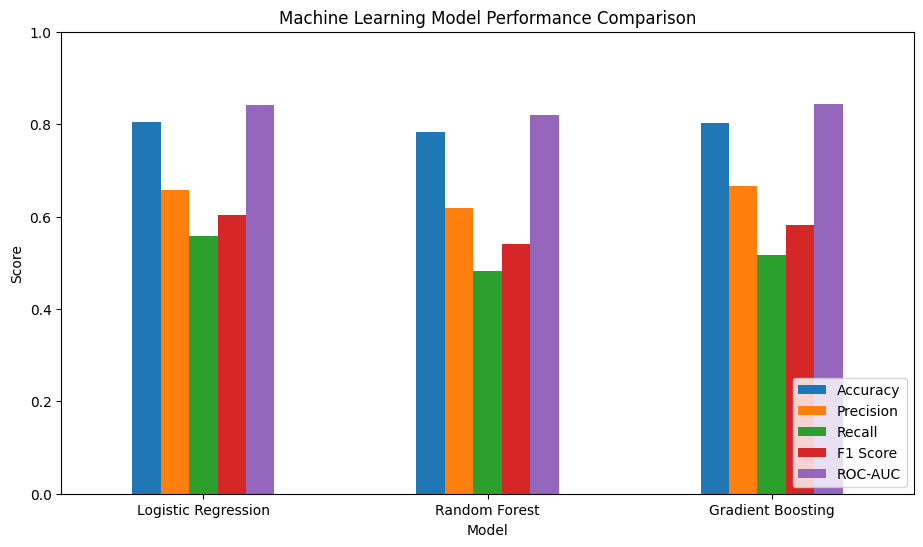

In [138]:
# Compare model performance visually

comparison_plot = model_results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
]

comparison_plot.plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title('Machine Learning Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.show()

### Model Comparison and Selection

Three classification models were evaluated using the same training and testing datasets: Logistic Regression, Random Forest, and Gradient Boosting.

The results show that no single model dominates every evaluation metric.

- **Logistic Regression** achieved the highest accuracy (80.55%), recall (55.88%), and F1-score (60.40%).
- **Gradient Boosting** achieved the highest precision (66.55%) and ROC-AUC (84.34%).
- **Random Forest** produced lower performance across most metrics in the current experiment.

Gradient Boosting achieved the highest ROC-AUC, although the difference compared with Logistic Regression was very small (0.8434 vs. 0.8421).

For this customer churn problem, recall is particularly important because a false negative represents a customer who actually churns but is not identified as being at risk. Missing these customers may prevent the company from applying retention strategies.

Therefore, Logistic Regression is selected as the primary model because it provides the highest recall and F1-score while maintaining strong accuracy and ROC-AUC performance.

The comparison also demonstrates that a more complex model does not necessarily produce better results. Model selection should depend on the business objective and appropriate evaluation metrics rather than model complexity alone.

In [139]:
from sklearn.metrics import roc_curve

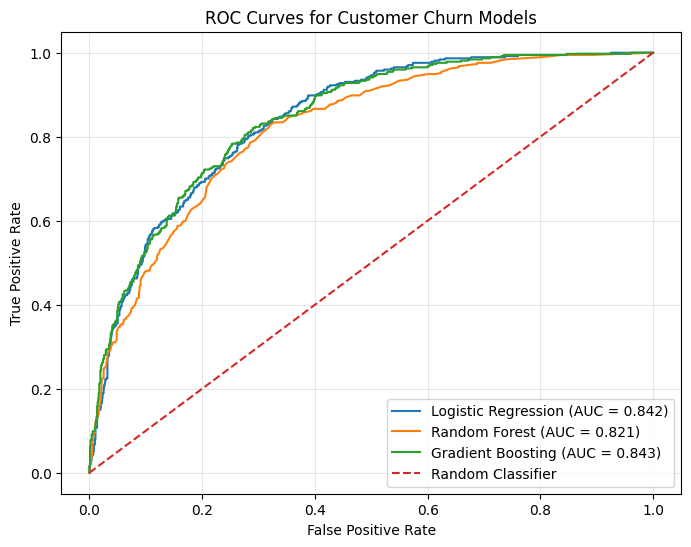

In [140]:
# Calculate ROC curves for all three models
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_gb, tpr_gb, _ = roc_curve(
    y_test,
    y_prob_gb
)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f'Logistic Regression (AUC = {logistic_roc_auc:.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {rf_roc_auc:.3f})'
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f'Gradient Boosting (AUC = {gb_roc_auc:.3f})'
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('ROC Curves for Customer Churn Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### ROC Curve Interpretation

The ROC curves compare the ability of the three models to distinguish between churned and non-churned customers across different classification thresholds.

Gradient Boosting achieved the highest ROC-AUC (0.8434), followed very closely by Logistic Regression (0.8421). Random Forest achieved a lower ROC-AUC of 0.8206.

The very small difference between Gradient Boosting and Logistic Regression indicates that both models have similar overall discrimination ability. Logistic Regression remains the selected primary model because it achieved better recall and F1-score at the default classification threshold.

In [141]:
# Get feature names after preprocessing
feature_names = logistic_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = logistic_model.named_steps[
    'classifier'
].coef_[0]

# Create coefficient DataFrame
feature_effects = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by coefficient
feature_effects = feature_effects.sort_values(
    by='Coefficient',
    ascending=False
)

print("Features most associated with higher predicted churn:")
display(feature_effects.head(10))

print("\nFeatures most associated with lower predicted churn:")
display(feature_effects.tail(10))

Features most associated with higher predicted churn:


,Feature,Coefficient
16,cat__InternetService_Fiber optic,0.634195
36,cat__Contract_Month-to-month,0.582883
3,num__TotalCharges,0.536253
35,cat__StreamingMovies_Yes,0.200938
32,cat__StreamingTV_Yes,0.200481
43,cat__PaymentMethod_Electronic check,0.197867
18,cat__OnlineSecurity_No,0.156279
27,cat__TechSupport_No,0.131503
14,cat__MultipleLines_Yes,0.104649
0,num__SeniorCitizen,0.053449



Features most associated with lower predicted churn:


,Feature,Coefficient
19,cat__OnlineSecurity_No internet service,-0.300104
17,cat__InternetService_No,-0.300104
31,cat__StreamingTV_No internet service,-0.300104
25,cat__DeviceProtection_No internet service,-0.300104
22,cat__OnlineBackup_No internet service,-0.300104
39,cat__PaperlessBilling_No,-0.343227
2,num__MonthlyCharges,-0.591863
15,cat__InternetService_DSL,-0.648646
38,cat__Contract_Two year,-0.776594
1,num__tenure,-1.257539


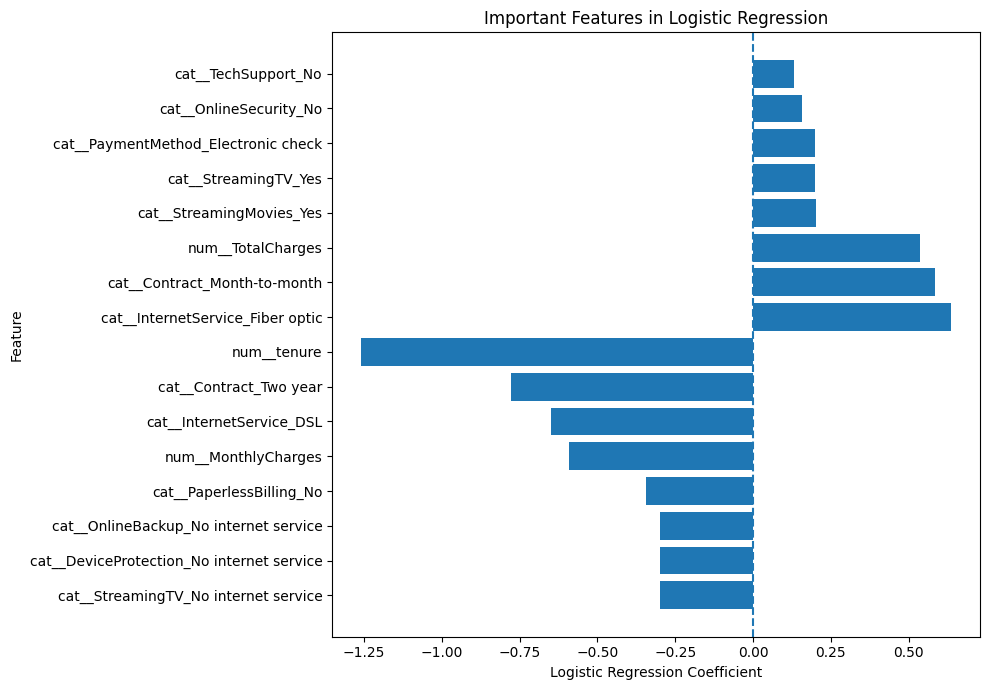

In [142]:
# Select strongest positive and negative coefficients
top_positive = feature_effects.head(8)
top_negative = feature_effects.tail(8)

important_features = pd.concat([
    top_negative,
    top_positive
])

# Plot coefficients
plt.figure(figsize=(10, 7))

plt.barh(
    important_features['Feature'],
    important_features['Coefficient']
)

plt.axvline(
    x=0,
    linestyle='--'
)

plt.title('Important Features in Logistic Regression')
plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [143]:
# Evaluate different classification thresholds
threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:

    predictions = (
        y_prob_logistic >= threshold
    ).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_test,
            predictions
        ),
        'Recall': recall_score(
            y_test,
            predictions
        ),
        'F1 Score': f1_score(
            y_test,
            predictions
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.30,0.5193,0.7540,0.6150
1,0.35,0.5432,0.7059,0.6140
2,0.40,0.5682,0.6684,0.6143
3,0.45,0.6021,0.6150,0.6085
4,0.50,0.6572,0.5588,0.6040


## 6. Model Interpretation and Business Insights

### Feature Interpretation

The Logistic Regression coefficients provide additional insight into the characteristics associated with predicted customer churn.

Several features are associated with a higher predicted probability of churn:

- Fiber optic internet service
- Month-to-month contracts
- Higher total charges
- Electronic check payments
- Lack of online security
- Lack of technical support
- Streaming TV and streaming movie services

Among these categorical features, fiber optic internet service and month-to-month contracts show particularly strong positive coefficients.

Several features are associated with a lower predicted probability of churn:

- Longer customer tenure
- Two-year contracts
- DSL internet service
- Customers without internet service
- Non-paperless billing

Customer tenure has the strongest negative coefficient in the model, suggesting that customers who have remained with the company for longer periods tend to have substantially lower predicted churn risk.

These relationships are associations learned by the model and should not be interpreted as proof that any individual feature directly causes customer churn.

### Connection with Exploratory Data Analysis

The model interpretation is broadly consistent with the earlier exploratory analysis.

For example:

- Month-to-month customers had a churn rate of approximately 42.71%, while two-year contract customers had a churn rate of only approximately 2.83%.
- Fiber optic customers had a churn rate of approximately 41.89%.
- Electronic check customers had a churn rate of approximately 45.29%.
- Customers who churned had substantially shorter average tenure than customers who remained.

The consistency between the exploratory analysis and model coefficients increases confidence that these variables contain meaningful information for identifying customer churn risk.

### Classification Threshold Analysis

The default Logistic Regression classification threshold of 0.50 produced:

- Precision: 65.72%
- Recall: 55.88%
- F1-score: 60.40%

However, customer churn prediction is a business problem in which false negatives can be costly. A false negative represents a customer who actually churns but is not identified as being at risk.

To investigate this trade-off, several classification thresholds were evaluated.

Lowering the threshold increased recall:

- Threshold 0.50 → Recall 55.88%
- Threshold 0.45 → Recall 61.50%
- Threshold 0.40 → Recall 66.84%
- Threshold 0.35 → Recall 70.59%
- Threshold 0.30 → Recall 75.40%

At a threshold of 0.30, the model identifies approximately three-quarters of the customers who actually churn. The F1-score also slightly improves from 0.6040 at the default threshold to 0.6150.

The trade-off is lower precision. At the 0.30 threshold, precision decreases to approximately 51.93%, meaning that more non-churning customers will also be classified as high-risk.

### Business Interpretation

If the cost of contacting customers with retention offers is relatively low compared with the cost of losing a customer, a lower threshold such as 0.30 could be useful for identifying a broader group of at-risk customers.

If retention interventions are expensive, a higher threshold may be preferable because it provides higher precision.

Therefore, the classification threshold should ultimately be selected based on the business costs of false positives and false negatives rather than using 0.50 automatically.

## 7. Business Recommendations

Based on the exploratory analysis and machine learning results, several potential customer retention strategies can be considered.

### 1. Focus on New Customers

Customers who churn have substantially shorter tenure than retained customers. The company should pay particular attention to the early stages of the customer relationship.

Potential actions include improved onboarding, proactive customer support, and early satisfaction monitoring.

### 2. Encourage Longer-Term Contracts

Month-to-month customers show a substantially higher churn rate than customers with one-year or two-year contracts.

The company could consider incentives that encourage suitable customers to transition from month-to-month plans to longer-term contracts.

### 3. Investigate Fiber Optic Customer Experience

Fiber optic customers show a relatively high churn rate and fiber optic service is positively associated with predicted churn in the Logistic Regression model.

This does not prove that fiber optic service causes churn. Further analysis should investigate possible explanations such as pricing, service quality, customer expectations, or differences in customer characteristics.

### 4. Review Electronic Check Customers

Customers using electronic checks show a higher churn rate than customers using other payment methods.

The company could investigate whether payment experience, customer characteristics, or other factors explain this association and potentially encourage convenient automatic payment options where appropriate.

### 5. Target Retention Campaigns Using Churn Risk

The machine learning model can be used to identify customers with elevated predicted churn risk.

For broader retention screening, lowering the classification threshold from 0.50 to approximately 0.30 substantially increases recall. This allows the company to identify more customers who eventually churn, although it also increases the number of false-positive alerts.

The appropriate threshold should therefore depend on the cost of retention interventions compared with the cost of customer churn.

## 8. Final Conclusion

This project demonstrated an end-to-end AI-assisted data science workflow for customer churn prediction using the Telco Customer Churn dataset.

The analysis included:

- Business and data understanding
- Data quality assessment and cleaning
- Exploratory data analysis
- Feature preprocessing
- Logistic Regression
- Random Forest
- Gradient Boosting
- Multi-metric model evaluation
- ROC analysis
- Feature interpretation
- Classification threshold analysis
- Business recommendations

Among the three models evaluated, Logistic Regression was selected as the primary model. It achieved:

- **Accuracy:** 80.55%
- **Precision:** 65.72%
- **Recall:** 55.88%
- **F1-score:** 60.40%
- **ROC-AUC:** 84.21%

Gradient Boosting achieved a slightly higher ROC-AUC of 84.34%, but Logistic Regression provided better recall and F1-score at the default classification threshold.

The exploratory analysis and model interpretation consistently identified several characteristics associated with customer churn, including shorter tenure, month-to-month contracts, fiber optic internet service, electronic check payments, and higher monthly charges.

The threshold experiment further demonstrated that model deployment decisions should consider business objectives. Lowering the Logistic Regression threshold from 0.50 to 0.30 increased churn recall from 55.88% to 75.40%, allowing the model to identify substantially more customers who eventually churn at the cost of lower precision.

Overall, the project demonstrates that successful data science involves more than maximizing a single model metric. Data quality, exploratory analysis, model comparison, interpretation, business objectives, and the trade-off between different types of prediction errors all influence the final decision.